# 09 -- CLI Workflows from Python: `vdl` via `subprocess`

The `vdl` command-line interface is the most reproducible way to drive
venn-diagram-lab in a pipeline -- inputs and outputs are files, so every
step is hashable and cacheable. But many users prefer Python notebooks for
exploration and orchestration. This notebook bridges the gap: every demo
shells out to `vdl` via `subprocess`, parses the result back into Python,
and treats the CLI as a building block for richer scripts.

**Audience:** pipeline users who script with Python but want to use the CLI
for reproducible batch runs (CI, Snakemake, Nextflow, ad-hoc parallelisation).

**What you will learn:**

- How to discover the CLI surface (`vdl tree`, `vdl <sub> --help`)
- How to capture and parse `vdl` stdout (TSV, JSON)
- How to drive a multi-output run from a YAML config
- How to bundle results into a ZIP for sharing
- When the CLI is the right tool vs the Python API


In [1]:
import json
import subprocess
import sys
from pathlib import Path

# Derive the `vdl` executable from the active Python interpreter's bin dir
# so the notebook works regardless of whether `vdl` is on PATH.
VDL = str(Path(sys.executable).parent / 'vdl')
print('Using vdl:', VDL)

Using vdl: /Users/Zoli/anaconda3/bin/vdl


## 1. Discover the full CLI surface with `vdl tree`

`vdl tree` prints every subcommand grouped by subapp. Use it as a
self-documenting map -- no man pages required.


In [2]:
r = subprocess.run([VDL, 'tree'], capture_output=True, text=True, check=True)
print(r.stdout)

vdl
├── about  — Show a short overview of Venn diagrams (abridged from the webtool).
├── analyze  — Analyze a dataset and write outputs (or print summary if none specified).
├── cluster  — Render cluster-rendered heatmap (shortcut for `render heatmap --cluster`).
├── credits  — Show authors, citation, and links to the webtool / Zenodo / PyPI / CRAN.
├── data  — Data operations (validate, describe, convert, fit-model, samples).
│   ├── convert  — Convert between TSV and CSV formats.
│   ├── describe  — Print a quick text summary of the dataset.
│   ├── fit-model  — Recommend a model name for the dataset's set count.
│   ├── lookup  — Find which Venn region(s) contain a given item.
│   ├── samples  — List bundled sample datasets (plain-text, one per line).
│   └── validate  — Validate a dataset's schema and contents.
├── export  — Export TSV tables (region summary, matrix, statistics, pairwise).
│   ├── matrix  — Write the binary item-by-set membership matrix TSV.
│   ├── pairwise  — Ali

## 2. Drill into a subapp with `--help`

Every command and subapp supports `--help`. Two of the most useful
subapps are `render` (visual outputs) and `data` (input hygiene).


In [3]:
r = subprocess.run([VDL, 'render', '--help'], capture_output=True, text=True, check=True)
print(r.stdout)

                                                                                
 Usage: vdl render [OPTIONS] COMMAND [ARGS]...                                  
                                                                                
 Render visual outputs (Venn / UpSet / Network / Heatmap / Histogram).          
                                                                                
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --help          Show this message and exit.                                  │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─ Commands ───────────────────────────────────────────────────────────────────╮
│ all          Render Venn + UpSet + Network + Heatmap + ShareDist into one    │
│              directory.                                                      │
│ bar          Render the pairwise-enrichment bar chart.                       │
│ heatmap      Render the pa

In [4]:
r = subprocess.run([VDL, 'data', '--help'], capture_output=True, text=True, check=True)
print(r.stdout)

                                                                                
 Usage: vdl data [OPTIONS] COMMAND [ARGS]...                                    
                                                                                
 Data operations (validate, describe, convert, fit-model, samples).             
                                                                                
╭─ Options ────────────────────────────────────────────────────────────────────╮
│ --help          Show this message and exit.                                  │
╰──────────────────────────────────────────────────────────────────────────────╯
╭─ Commands ───────────────────────────────────────────────────────────────────╮
│ convert     Convert between TSV and CSV formats.                             │
│ describe    Print a quick text summary of the dataset.                       │
│ fit-model   Recommend a model name for the dataset's set count.              │
│ lookup      Find which Ven

## 3. Demo 1: render a Venn SVG and display it inline

`vdl render venn --sample --out /tmp/v.svg` writes an SVG file. From the
notebook we then read it back and let IPython display it inline.


Wrote /tmp/v.svg
Wrote /tmp/v.svg (6,254 bytes)


note: --sample → using bundled 'dataset_real_cancer_drivers_4'


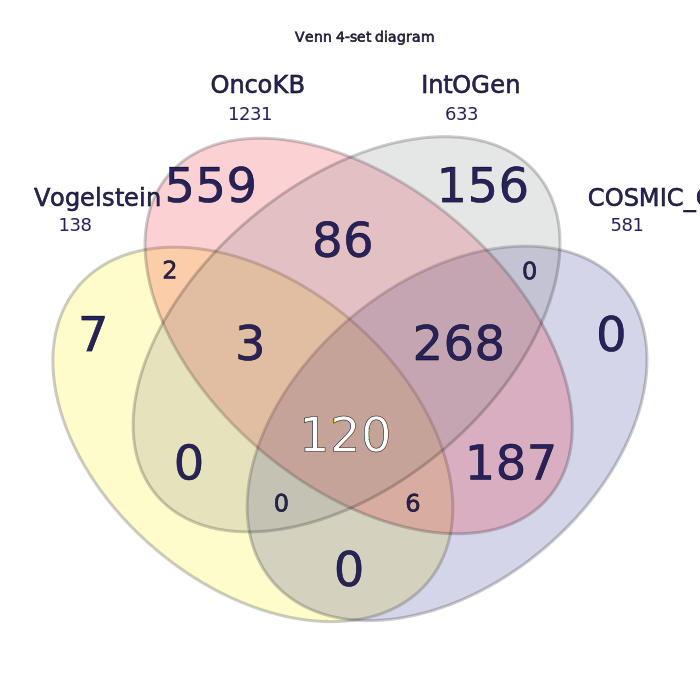

In [5]:
from IPython.display import SVG, display

out_svg = Path('/tmp/v.svg')
subprocess.run(
    [VDL, 'render', 'venn', '--sample', '--out', str(out_svg)],
    check=True,
)
print(f'Wrote {out_svg} ({out_svg.stat().st_size:,} bytes)')
display(SVG(filename=str(out_svg)))

## 4. Demo 2: capture statistics TSV from stdout into pandas

Most `vdl export` commands accept `--out -` to stream the TSV to stdout.
Combined with `io.StringIO`, you can pipe straight into pandas without
ever touching the filesystem.


In [6]:
import io

import pandas as pd

r = subprocess.run(
    [VDL, 'export', 'statistics', '--sample', '--out', '-'],
    capture_output=True, text=True, check=True,
)
df = pd.read_csv(io.StringIO(r.stdout), sep='\t')
print(f'Columns: {list(df.columns)}')
print(f'Rows: {len(df)}')
df.head()

Columns: ['Set_A', 'Set_B', 'Name_A', 'Name_B', 'Size_A', 'Size_B', 'Intersection', 'Union', 'Jaccard', 'Overlap_Coeff', 'Dice', 'Expected', 'Fold_Enrichment', 'P_value', 'FDR', 'Significant']
Rows: 6


,Set_A,Set_B,Name_A,Name_B,Size_A,Size_B,Intersection,Union,Jaccard,Overlap_Coeff,Dice,Expected,Fold_Enrichment,P_value,FDR,Significant
0,B,C,COSMIC_CGC,OncoKB,581,1231,581,1231,0.4720,1.0000,0.6413,35.76,16.247,0.000000e+00,0.000000e+00,***
1,B,D,COSMIC_CGC,IntOGen,581,633,388,826,0.4697,0.6678,0.6392,18.39,21.100,0.000000e+00,0.000000e+00,***
2,C,D,OncoKB,IntOGen,1231,633,477,1387,0.3439,0.7536,0.5118,38.96,12.243,0.000000e+00,0.000000e+00,***
3,A,B,Vogelstein,COSMIC_CGC,138,581,126,593,0.2125,0.9130,0.3505,4.01,31.430,6.750000e-184,1.010000e-183,***
4,A,D,Vogelstein,IntOGen,138,633,123,648,0.1898,0.8913,0.3191,4.37,28.161,4.610000e-171,5.540000e-171,***


## 5. Demo 3: parse `vdl data validate` JSON output

`vdl data validate` emits a structured JSON report by default --
perfect for programmatic checking in a pipeline.


In [7]:
r = subprocess.run(
    [VDL, 'data', 'validate', '--sample'],
    capture_output=True, text=True, check=True,
)
report = json.loads(r.stdout)
print('Top-level keys:', list(report.keys()))
print('Sets         :', report['sets'])
print('Item count   :', report['item_count'])
print('Errors       :', report['errors'])
print('Exit code    :', report['exit_code'])

Top-level keys: ['input', 'sets', 'item_count', 'errors', 'warnings', 'info', 'exit_code']
Sets         : ['Vogelstein', 'COSMIC_CGC', 'OncoKB', 'IntOGen']
Item count   : 1394
Errors       : []
Exit code    : 0


## 6. Demo 4: run a YAML workflow with `vdl workflow run-from`

Write a small `analysis.yaml`, then point `vdl workflow run-from` at it.
Each output is dispatched to the appropriate renderer / exporter, and the
final directory contains every artefact described in the config.


In [8]:
import tempfile

tmp = Path(tempfile.mkdtemp(prefix='vdl_wf_'))
yaml_text = '''\
version: 1
input: dataset_real_cancer_drivers_4
model: auto
outputs:
  - kind: venn
    out: ''' + str(tmp / 'venn.svg') + '''
  - kind: upset
    out: ''' + str(tmp / 'upset.svg') + '''
  - kind: statistics
    out: ''' + str(tmp / 'statistics.tsv') + '''
'''
yaml_path = tmp / 'analysis.yaml'
yaml_path.write_text(yaml_text)
r = subprocess.run(
    [VDL, 'workflow', 'run-from', str(yaml_path)],
    capture_output=True, text=True, check=True,
)
print(r.stdout)
print('Files in', tmp, ':')
for f in sorted(tmp.iterdir()):
    print(f'  {f.name:<25}  {f.stat().st_size:>8,} bytes')

[1/3] venn -> /var/folders/ww/fsvzxkwx6hgfzqbq08lfrqdc0000gn/T/vdl_wf_s3fqql2s/venn.svg
[2/3] upset -> /var/folders/ww/fsvzxkwx6hgfzqbq08lfrqdc0000gn/T/vdl_wf_s3fqql2s/upset.svg
[3/3] statistics -> /var/folders/ww/fsvzxkwx6hgfzqbq08lfrqdc0000gn/T/vdl_wf_s3fqql2s/statistics.tsv
done.

Files in /var/folders/ww/fsvzxkwx6hgfzqbq08lfrqdc0000gn/T/vdl_wf_s3fqql2s :
  analysis.yaml                   377 bytes
  statistics.tsv                  704 bytes
  upset.svg                    48,337 bytes
  venn.svg                      6,254 bytes


## 7. Demo 5: bundle outputs into a ZIP with `vdl report zip`

`vdl report zip` packs the PDF report and every TSV/SVG into a single
ZIP file -- ideal for emailing a colleague or attaching to a paper.


In [9]:
import zipfile

out_zip = Path('/tmp/bundle.zip')
subprocess.run(
    [VDL, 'report', 'zip', '--sample', '--out', str(out_zip)],
    check=True,
)
print(f'Wrote {out_zip} ({out_zip.stat().st_size:,} bytes)')
with zipfile.ZipFile(out_zip) as z:
    for info in z.infolist():
        print(f'  {info.filename:<40}  {info.file_size:>8,} bytes')

note: --sample → using bundled 'dataset_real_cancer_drivers_4'


Wrote /tmp/bundle.zip
Wrote /tmp/bundle.zip (278,660 bytes)
  README.txt                                   8,372 bytes
  enrichment_statistics_4-sets.xlsx            6,922 bytes
  items_matrix.tsv                            23,382 bytes
  network.svg                                 15,198 bytes
  regions_summary.tsv                          8,897 bytes
  report.pdf                                 266,835 bytes
  share-dist.svg                               1,685 bytes
  statistics.tsv                                 704 bytes
  upset.svg                                   48,337 bytes
  venn.svg                                     6,254 bytes


## When to use the CLI vs the Python API

Both interfaces share the same engine, so output bytes are identical.
The right choice depends on *who* is calling and *why*.

| Use case | Prefer CLI | Prefer Python API |
|----------|-----------|------------------|
| Reproducible batch run (CI, Snakemake, cron) | Yes -- file-in/file-out is hashable | -- |
| Interactive exploration (Jupyter) | -- | Yes -- inspect `result.regions` |
| Custom post-processing of statistics | -- | Yes -- direct pandas access |

A common pattern is **both**: use the CLI for production pipelines, but
develop the analysis interactively with the Python API first, then
translate the proven workflow into an `analysis.yaml` for the CLI.


## Next steps

- [`06_pipeline_integration.ipynb`](06_pipeline_integration.ipynb) -- Snakemake and Nextflow integration patterns
- [`11_data_validation_and_lookup.ipynb`](11_data_validation_and_lookup.ipynb) -- deeper dive into `vdl data validate` and `vdl data lookup` workflows
